# Testing Plots


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde

In [2]:
# change here directories
csv_dir = '../../fasta_files/human/sarscov2/merged_gc.csv'
outputs_dir = '../../fasta_files/human/sarscov2/results/'

### Trying to recriate article plot

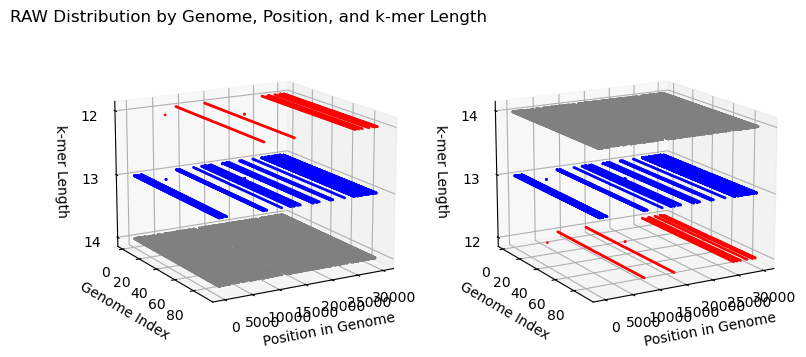

In [8]:
# 1) Load CSV -------------------------------------------------------------
df = pd.read_csv(
    '../../fasta_files/human/sarscov2/merged_gc.csv',
    header=None,
    names=["genome_idx", "position", "raw", "gc_pct", "kmer_len"]
)


# 2) Extract numeric columns and define colors ----------------------------
# df = df[df["genome_idx"] == 110].copy()
x = df["genome_idx"]
y = df["position"]
z = df["kmer_len"]

colors = df["kmer_len"]
k_colors = {12: "red", 13: "blue" , 14: "grey"}

# 3) 3D scatter -----------------------------------------------------------
fig = plt.figure(figsize=(9, 15))
ax1 = fig.add_subplot(1,2,1, projection="3d")

ax1.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=1,               # dot size
    alpha=0.9,
    depthshade=False
)

ax1.zaxis._axinfo['juggled'] = (1, 2, 0)  # moves the Z-axis pane to the left

# 4) Labels & appearance --------------------------------------------------
ax1.set_title("RAW Distribution by Genome, Position, and k-mer Length")
ax1.set_xlabel("Genome Index")
ax1.set_ylabel("Position in Genome")
ax1.set_zlabel("k-mer Length")

ax1.set_zticks(np.arange(z.min(), z.max() + 1, 1))
# ax.set_box_aspect([1, 4, 0.5])   # compress z-axis physically
ax1.invert_zaxis()

ax1.grid(True, linestyle=":", alpha=0.6)
ax1.view_init(elev=15, azim=-30)

ax2 = fig.add_subplot(1,2,2, projection="3d")

ax2.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=1,               # dot size
    alpha=0.9,
    depthshade=False
)
ax2.zaxis._axinfo['juggled'] = (1, 2, 0)  # moves the Z-axis pane to the left

# 4) Labels & appearance --------------------------------------------------
ax2.set_xlabel("Genome Index")
ax2.set_ylabel("Position in Genome")
ax2.set_zlabel("k-mer Length")

ax2.set_zticks(np.arange(z.min(), z.max() + 1, 1))

ax2.grid(True, linestyle=":", alpha=0.6)
ax2.view_init(elev=15, azim=-30)
plt.savefig(f"{outputs_dir}3d_raws_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


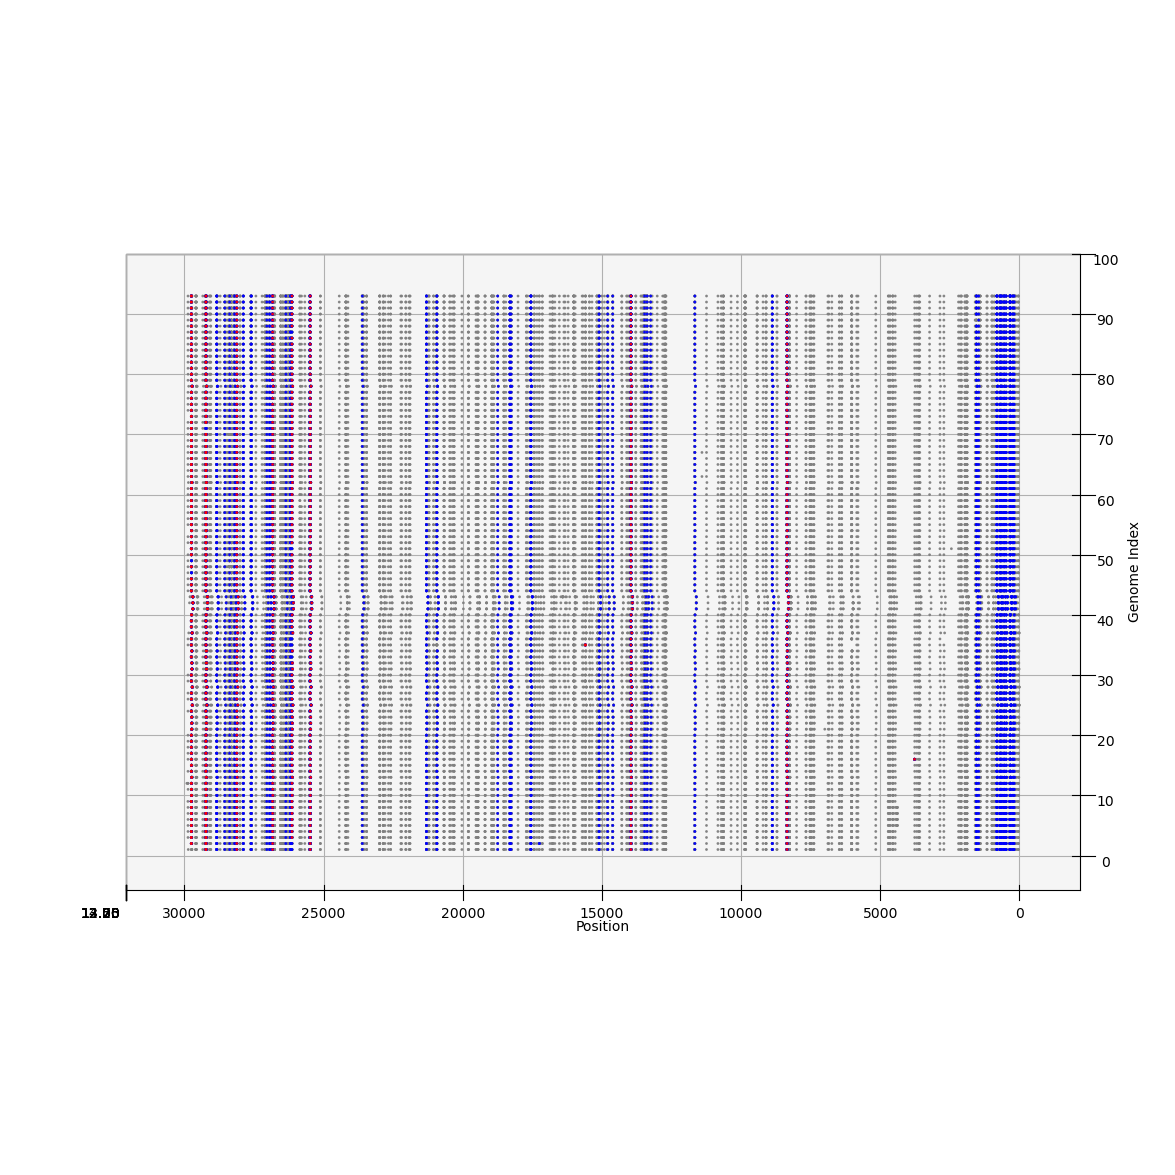

In [10]:
# --- Top-down (up) view ---
fig2 = plt.figure(figsize=(15, 15))
ax3 = fig2.add_subplot(projection="3d")

ax3.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=1,               # dot size
    alpha=0.9
)
ax3.set_xlabel("Genome Index")
ax3.set_ylabel("Position")

ax3.set_xticks(np.arange(0, x.max() + 10, 10))

ax3.invert_zaxis()

ax3.view_init(elev=90, azim=180)    # directly above
ax3.set_proj_type('ortho')        # removes perspective (flat view)
ax3.set_box_aspect([2, 3, 1])  # elongate Y
ax3.yaxis.set_label_coords(-0.05, 0.5)
plt.savefig(f"{outputs_dir}3d_raws_distribution_topdown.png", dpi=300, bbox_inches='tight')
plt.show()

### GC vs K plot

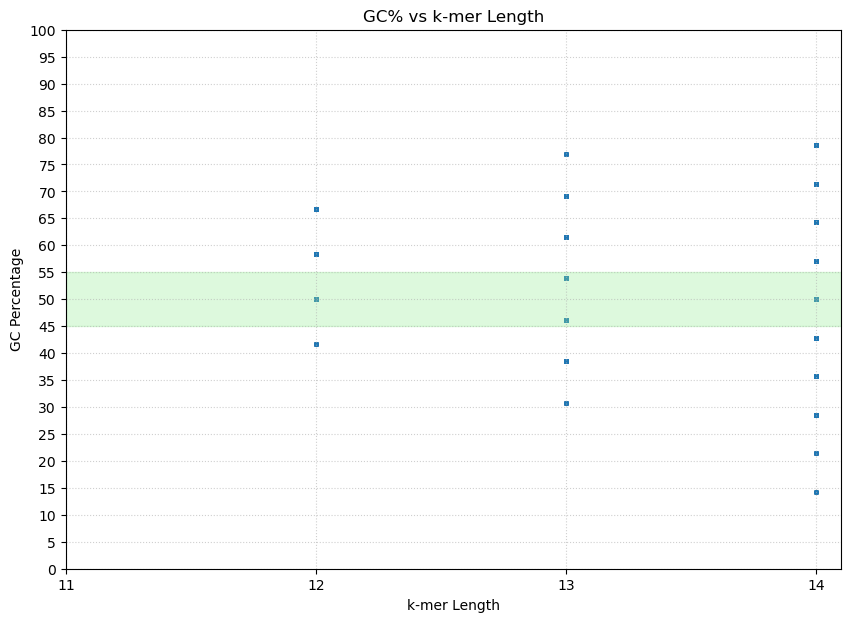

In [11]:
plt.figure(figsize=(10, 7))
plt.scatter(pd.to_numeric(df["kmer_len"]), df["gc_pct"], s=5, alpha=0.7)

plt.title("GC% vs k-mer Length")
plt.xlabel("k-mer Length")
plt.ylabel("GC Percentage")

plt.axhspan(45, 55, color='lightgreen', alpha=0.3)

plt.xticks(np.arange(11, 15, 1))  # from 0% to 100% every 5%
plt.yticks(np.arange(0, 101, 5))  # from 0% to 100% every 5%
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig(f"{outputs_dir}gc%_vs_kmer.png", dpi=300, bbox_inches='tight')
plt.show()

